In [20]:
import json
import os

import numpy as np
import pandas as pd

dir = '../data/results/experiments/new_beam_matching_experiment_8'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')

data_df

,errors,complexity,run,n_best_pcis,n_best_beams
0,0.793224,1497584.0,0.0,all,all
1,0.121086,1497584.0,0.0,all,all
2,0.151401,1497584.0,0.0,all,all
3,16.796982,1497584.0,0.0,all,all
4,0.786111,1497584.0,0.0,all,all
...,...,...,...,...,...
7358221,16.337820,1495230.0,14.0,24,8
7358222,0.434105,1495230.0,14.0,24,8
7358223,0.263764,1495230.0,14.0,24,8
7358224,0.070446,1495230.0,14.0,24,8


In [21]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    for i in range(errors.shape[0]):
        res.append((group[0], group[1], errors[i], complexity[i]))

df = pd.DataFrame(res, columns=['n_best_pcis', 'n_best_beams', 'errors', 'complexity'])

df

,n_best_pcis,n_best_beams,errors,complexity
0,1,1,45.815990,294800.0
1,1,1,44.686029,291350.0
2,1,1,43.395841,293750.0
3,1,1,42.675672,297150.0
4,1,1,45.210395,293750.0
...,...,...,...,...
2905,all,all,4.188503,1502410.0
2906,all,all,4.328401,1481836.0
2907,all,all,4.024363,1500632.0
2908,all,all,3.946083,1493520.0


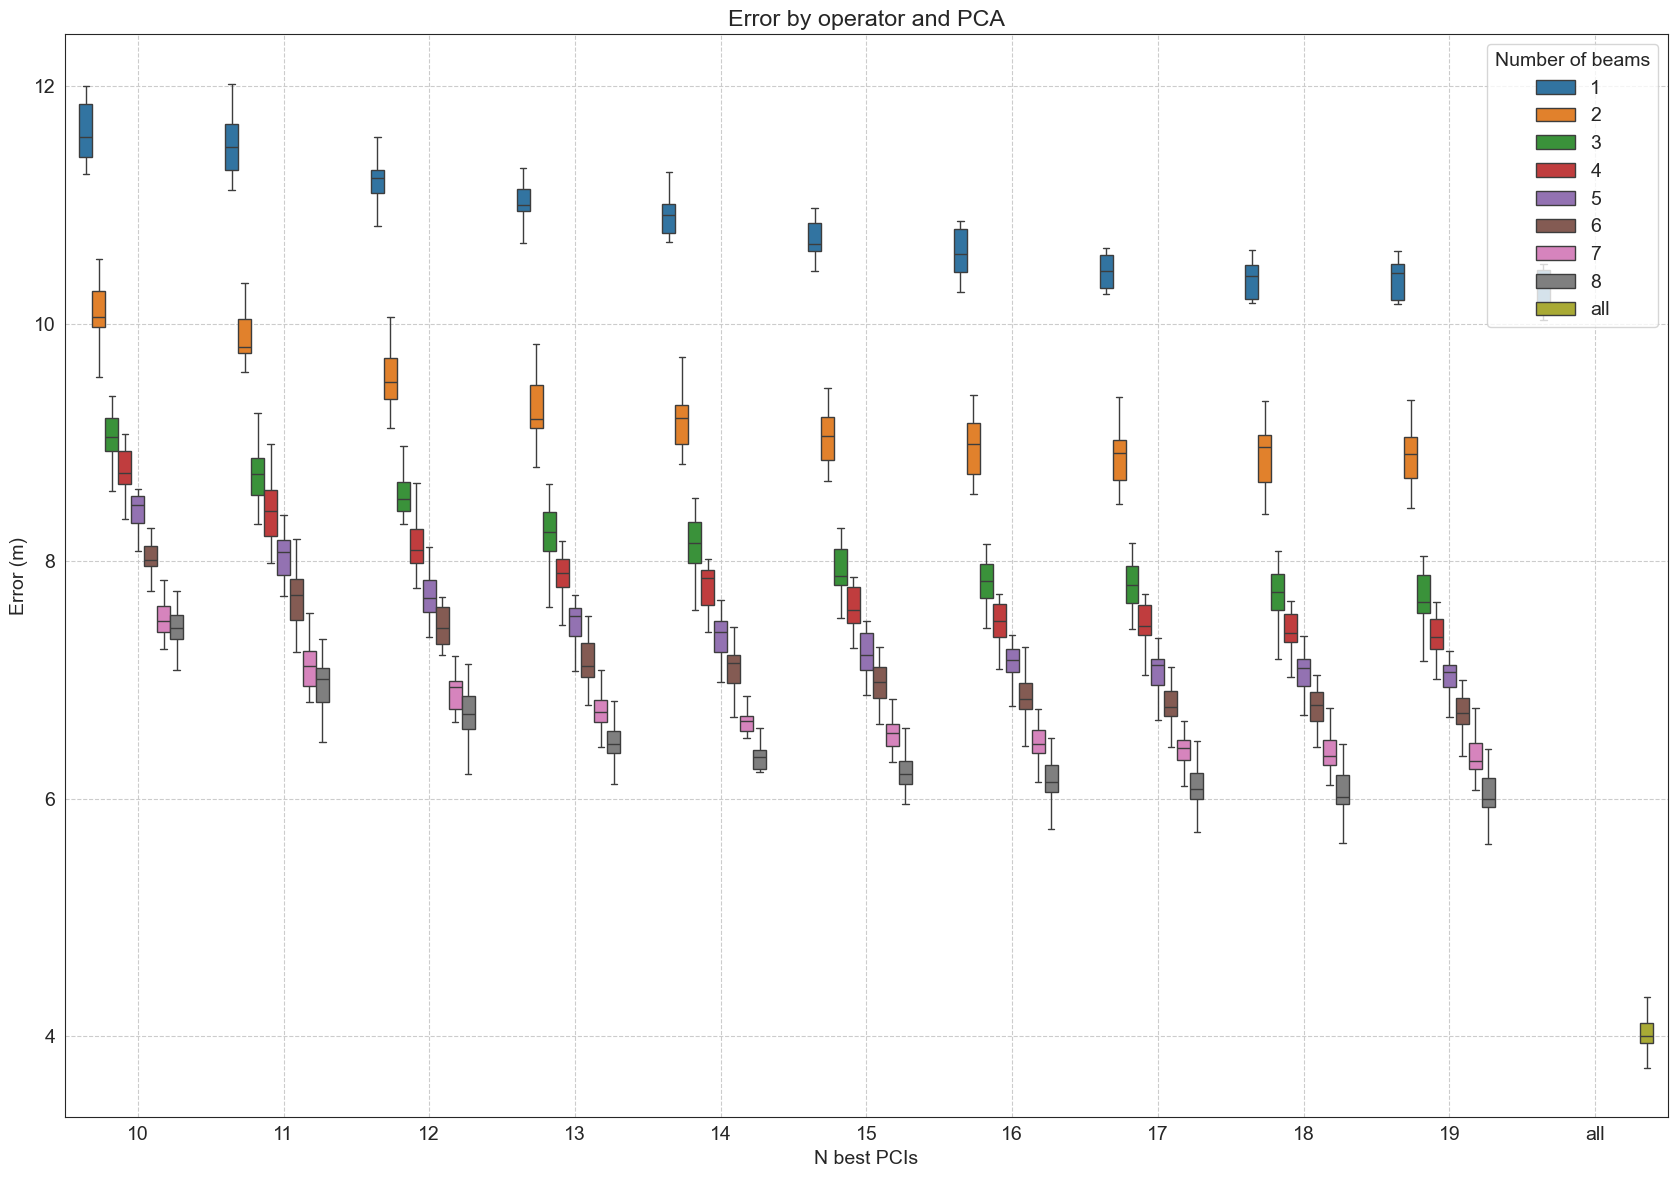

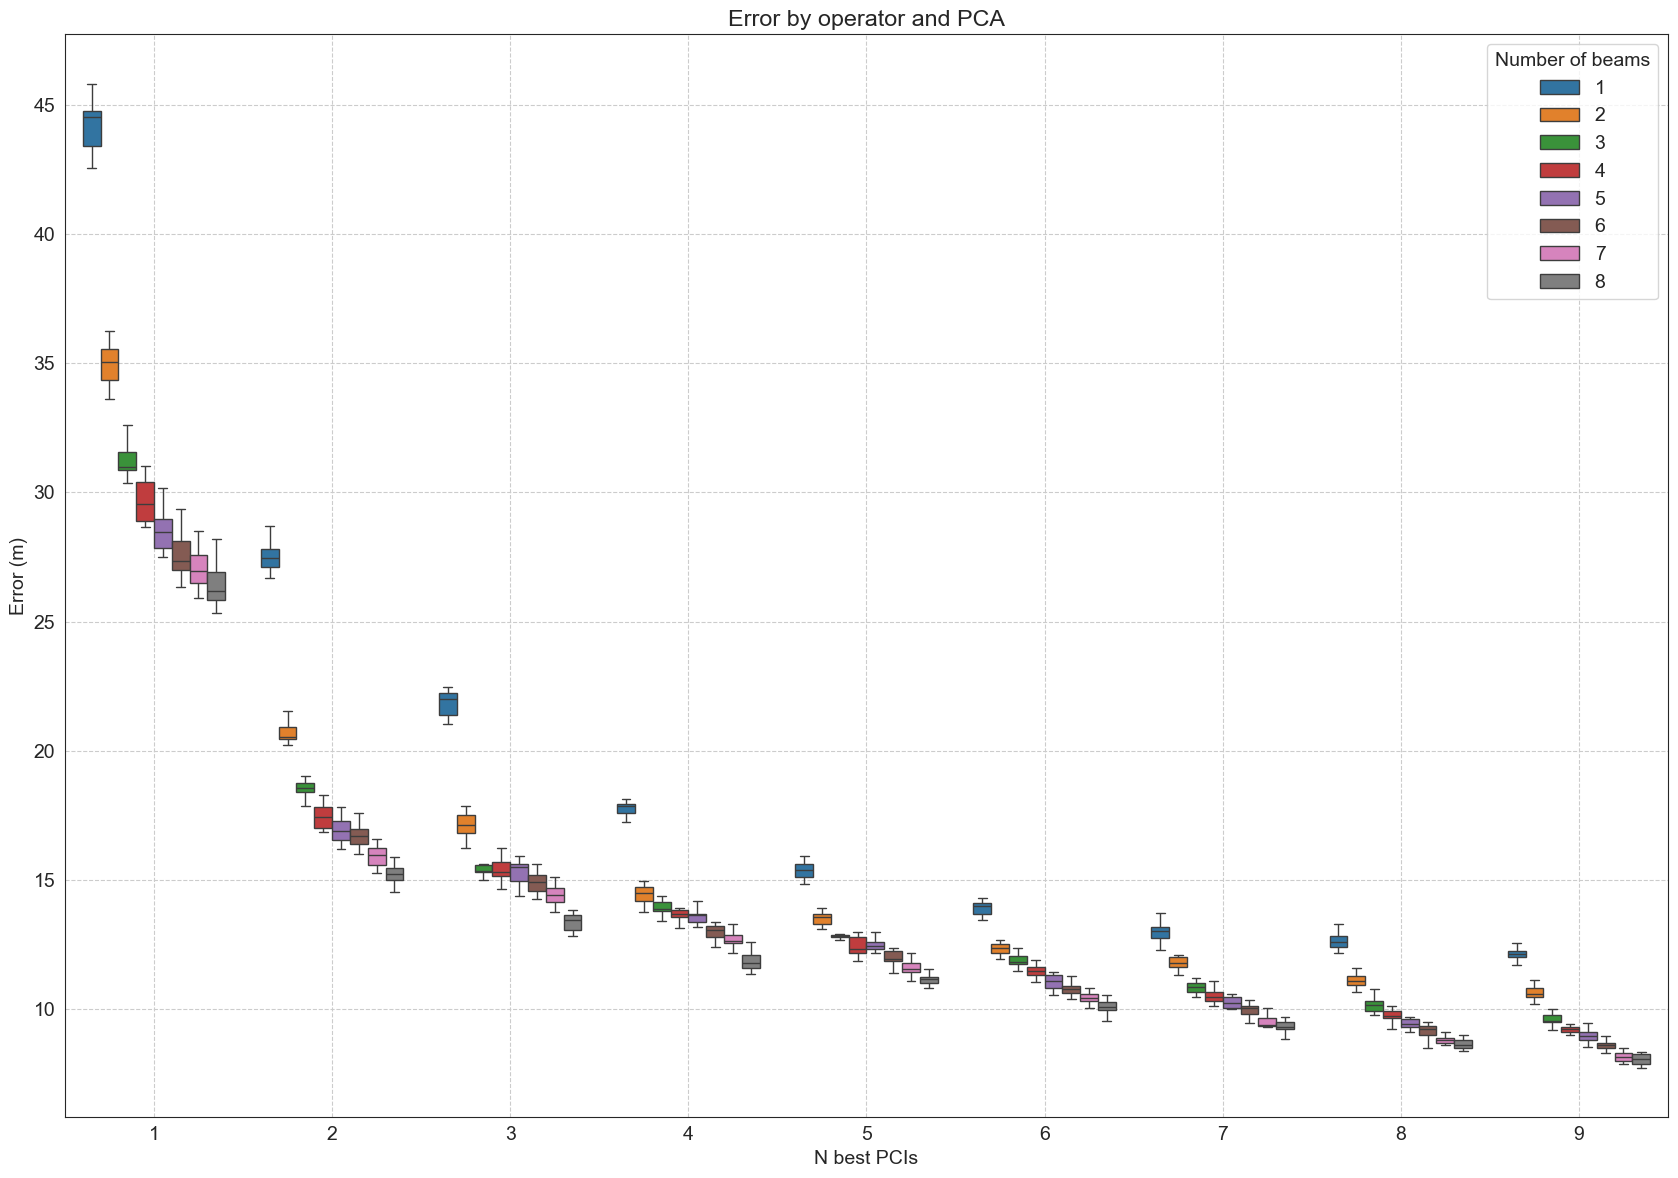

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]

#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

plot(df[df['n_best_pcis'].isin(highs)])
plot(df[df['n_best_pcis'].isin(lows)])

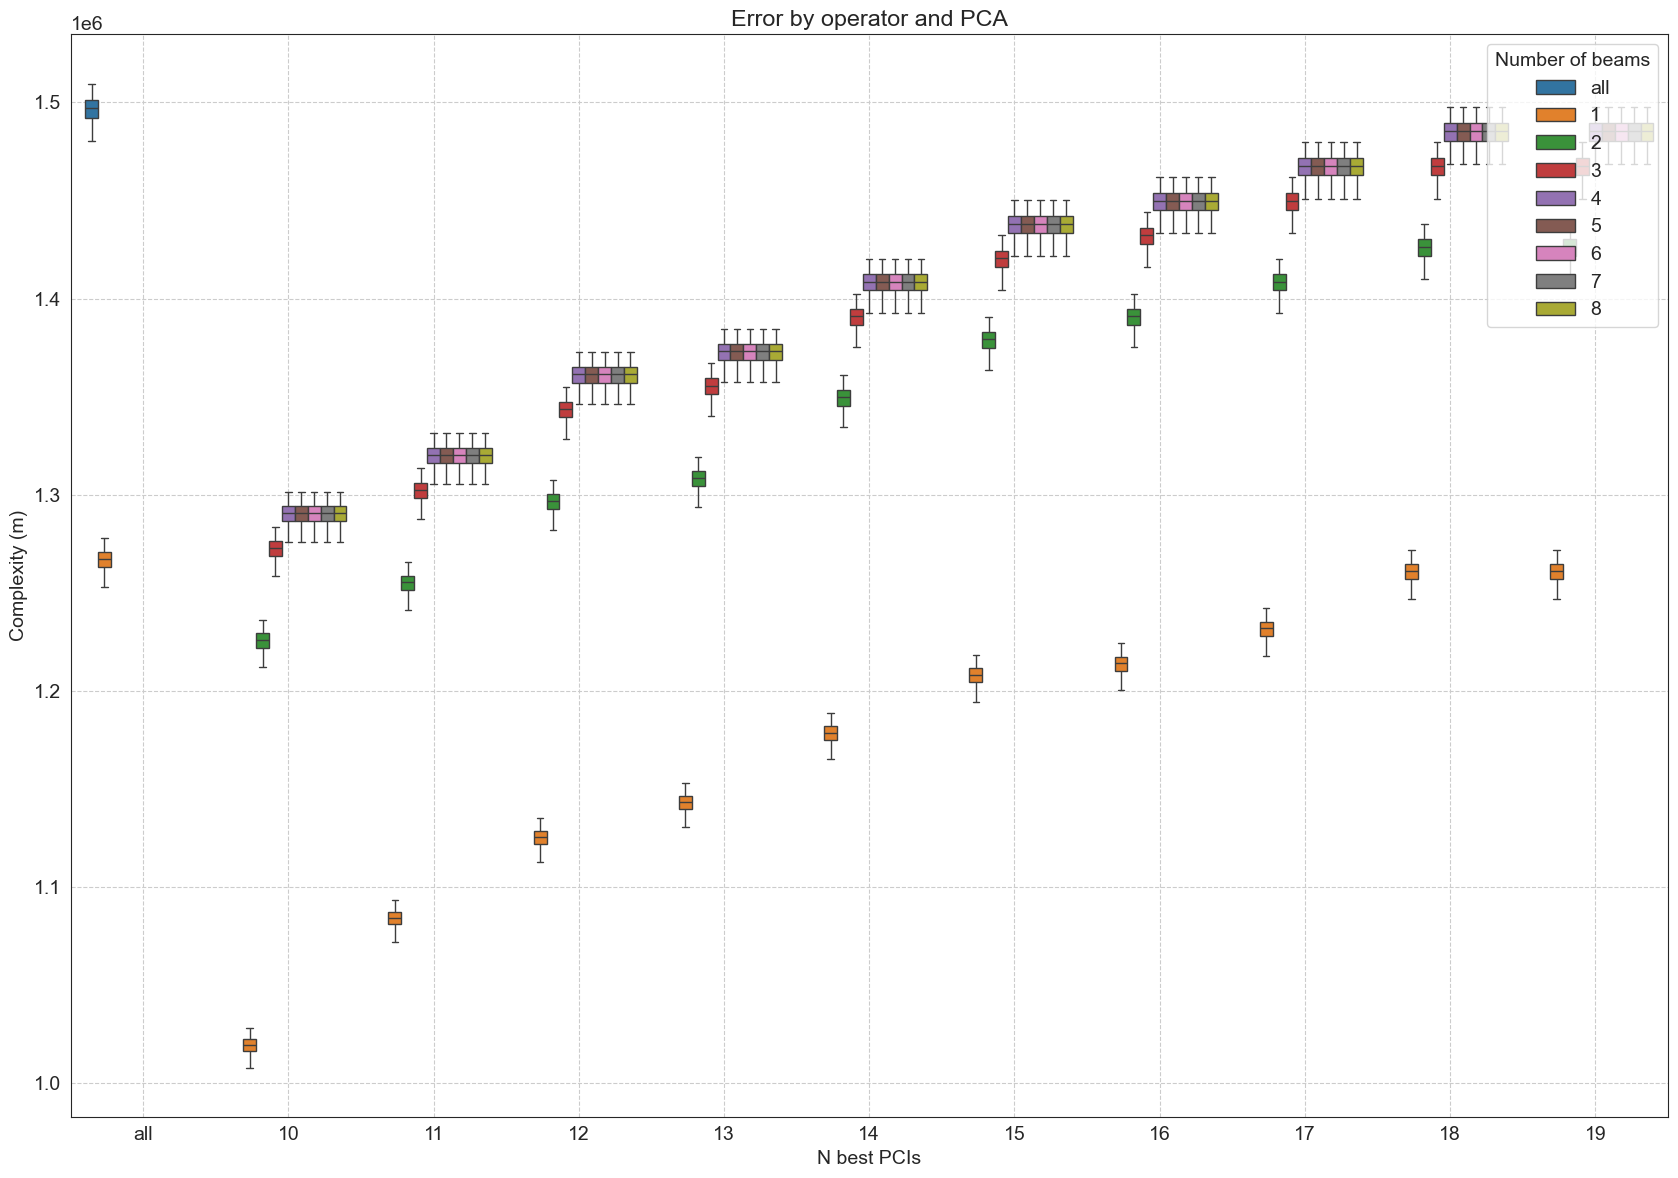

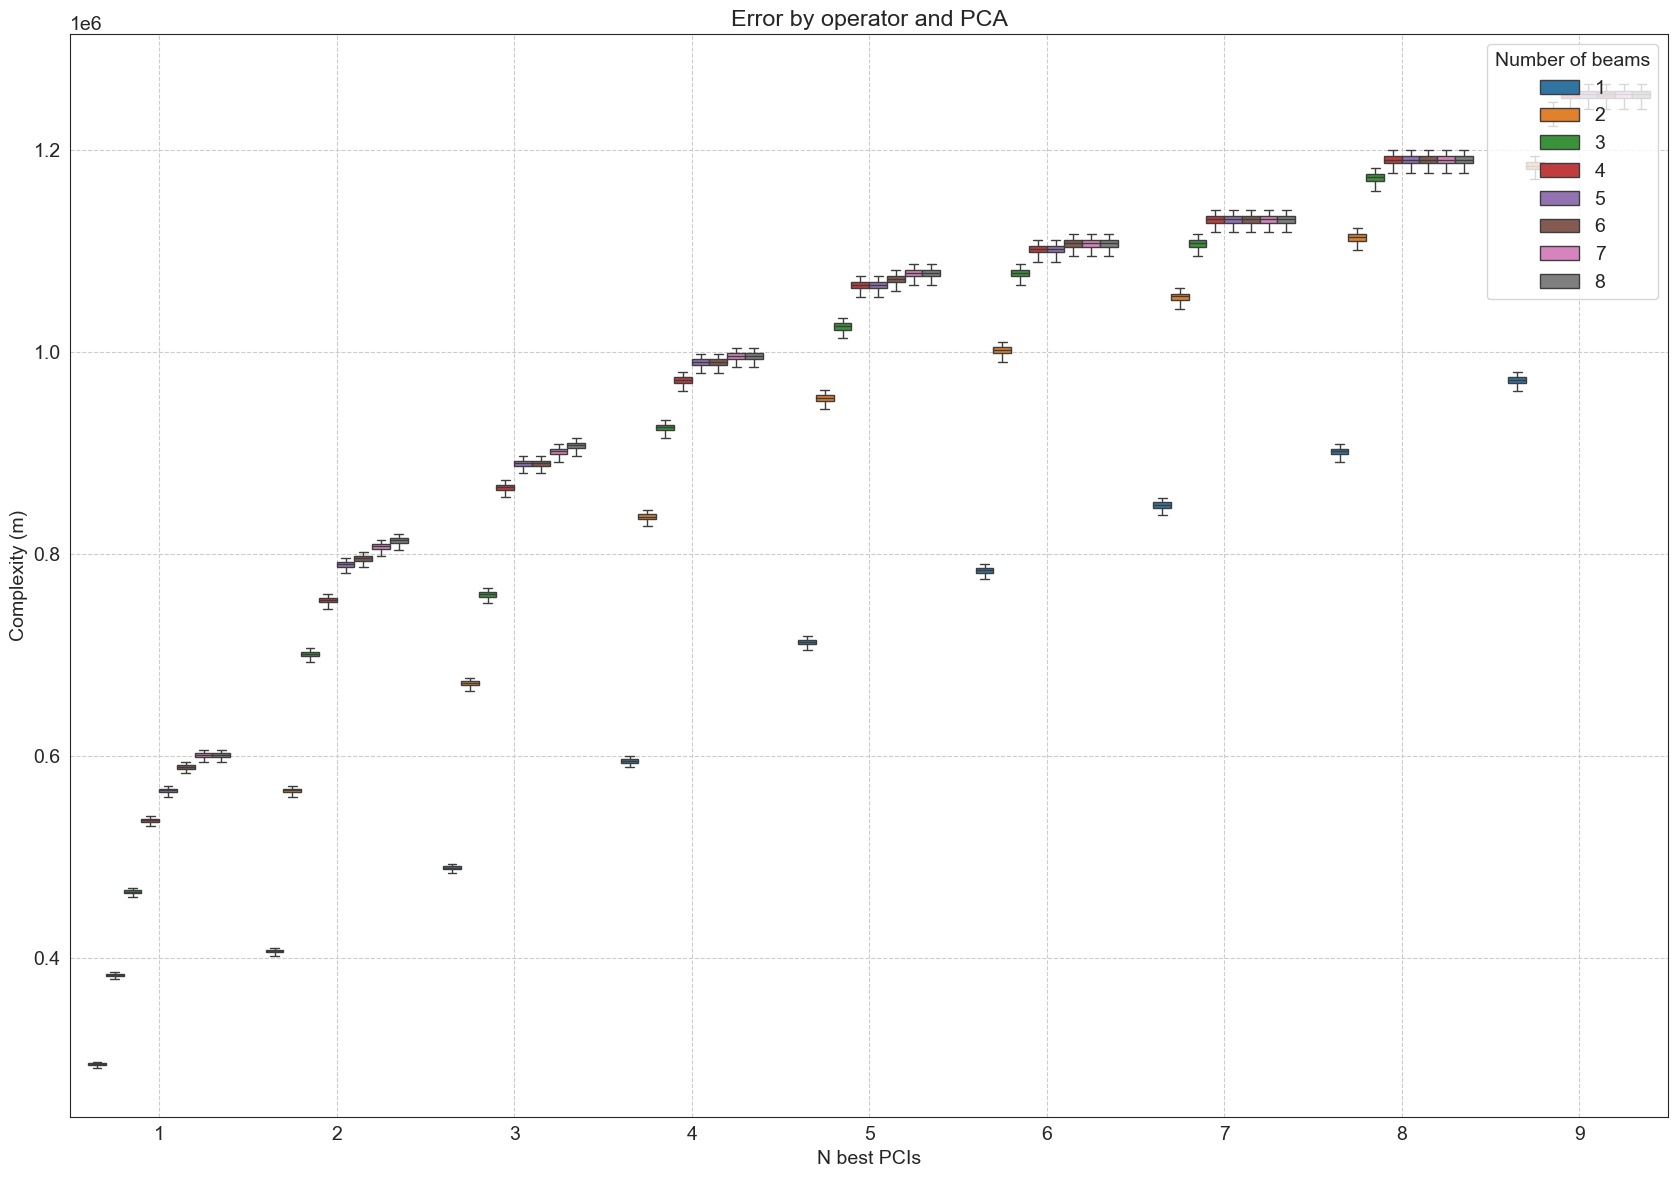

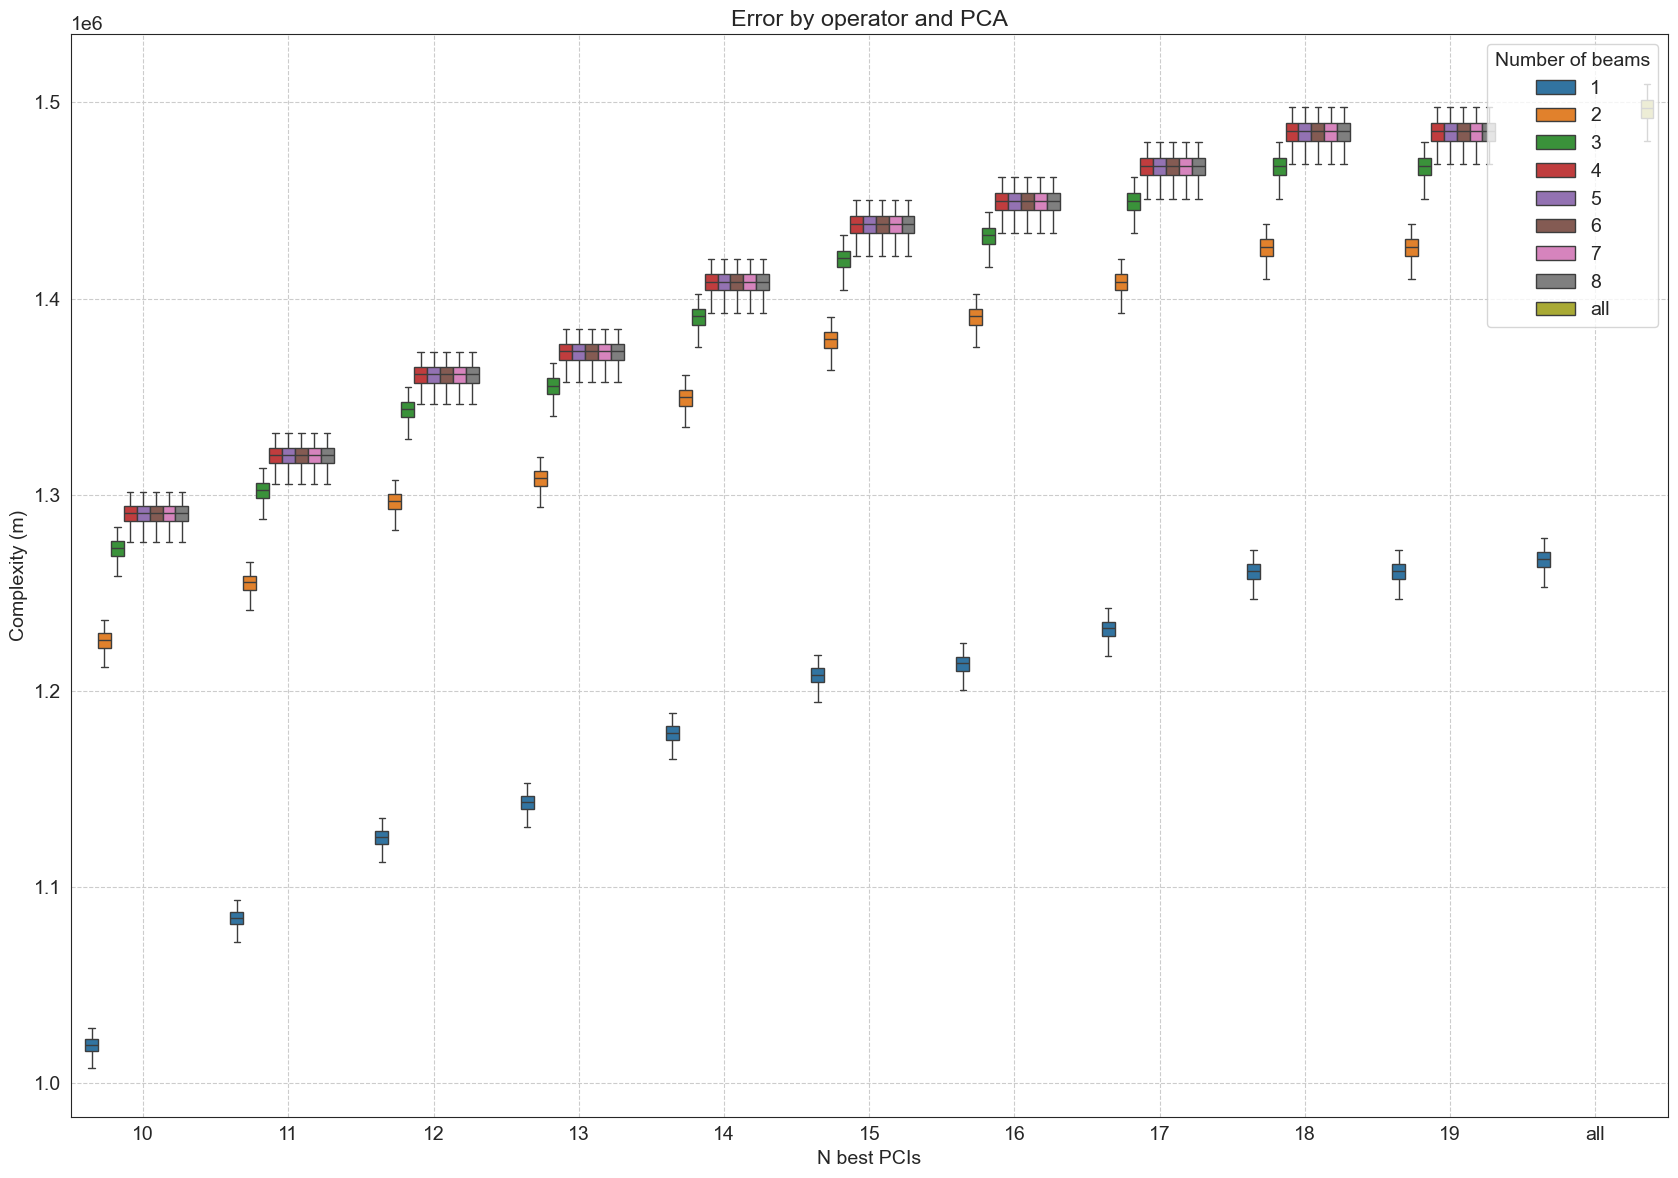

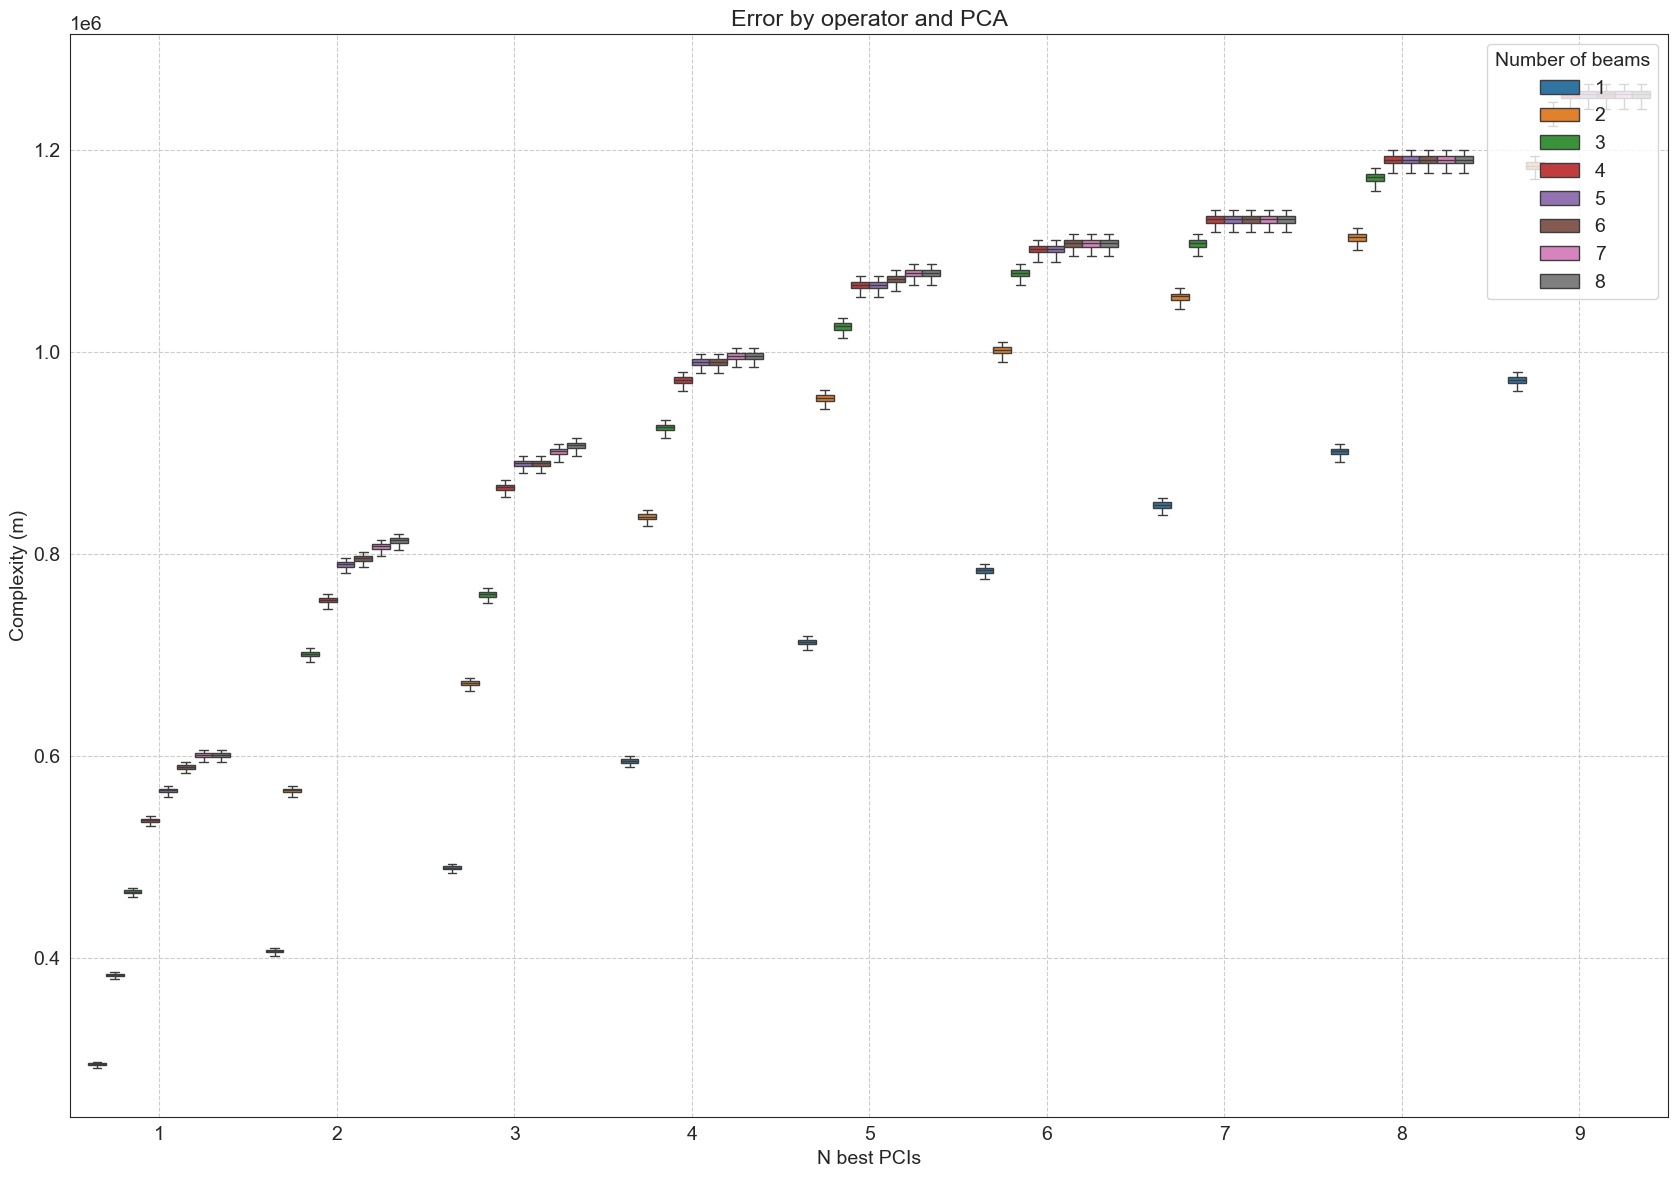

In [23]:

def plot_complexity(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Complexity (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]

plot_complexity(data_df[data_df['n_best_pcis'].isin(highs)])
plot_complexity(data_df[data_df['n_best_pcis'].isin(lows)])

plot_complexity(df[df['n_best_pcis'].isin(highs)])
plot_complexity(df[df['n_best_pcis'].isin(lows)])